In [1]:
import sys
sys.path.insert(0, '../src')

from utils.config import *
from utils.data import *
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.spatial import cKDTree
from sklearn.metrics import roc_auc_score
import os

os.makedirs('../visualizations_sf', exist_ok=True)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
os.makedirs('../visualizations_sf', exist_ok=True)

all_data    = load_folder('../data/train') + load_folder('../data/test')
crack_clouds = [d for d in all_data if d['has_crack']]
normal_clouds = [d for d in all_data if not d['has_crack']]

print(f"Nuvens de avaria: {len(crack_clouds)}")
print(f"Nuvens normais:   {len(normal_clouds)}")

20:55:11 | INFO | Encontrados 64 arquivos PLY em ../data/train
20:55:11 - INFO: Encontrados 64 arquivos PLY em ../data/train
20:55:12 | INFO |   OK avaria_10.ply | 7,971 pts | crack=True
20:55:12 - INFO:   OK avaria_10.ply | 7,971 pts | crack=True
20:55:13 | INFO |   OK avaria_12.ply | 7,636 pts | crack=True
20:55:13 - INFO:   OK avaria_12.ply | 7,636 pts | crack=True
20:55:14 | INFO |   OK avaria_13.ply | 11,880 pts | crack=True
20:55:14 - INFO:   OK avaria_13.ply | 11,880 pts | crack=True
20:55:19 | INFO |   OK avaria_17.ply | 24,367 pts | crack=True
20:55:19 - INFO:   OK avaria_17.ply | 24,367 pts | crack=True
20:55:22 | INFO |   OK avaria_19.ply | 22,914 pts | crack=True
20:55:22 - INFO:   OK avaria_19.ply | 22,914 pts | crack=True
20:55:25 | INFO |   OK avaria_2.ply | 23,988 pts | crack=True
20:55:25 - INFO:   OK avaria_2.ply | 23,988 pts | crack=True
20:55:28 | INFO |   OK avaria_20.ply | 15,509 pts | crack=True
20:55:28 - INFO:   OK avaria_20.ply | 15,509 pts | crack=True
20:55:

Nuvens de avaria: 32
Nuvens normais:   28


In [10]:
crack_clouds[1]

{'features': array([[-0.00328682, -0.66857743, -0.11595644, ...,  0.2071442 ,
          0.3620915 ,  0.09803921],
        [-0.00328682, -0.38565752,  0.04693631, ...,  0.23698723,
          0.34771243,  0.09019607],
        [-0.00328682,  0.24019533,  0.2741295 , ...,  0.39670658,
          0.3633987 ,  0.10196078],
        ...,
        [ 0.00099954,  0.28734934, -0.20168968, ...,  0.23613568,
          0.3633987 ,  0.06666666],
        [ 0.00099954,  0.27448824,  0.4241632 , ...,  0.27374724,
          0.35816994,  0.08235294],
        [ 0.00099954,  0.27448824,  0.23555025, ...,  0.18145558,
          0.3647059 ,  0.12156862]], shape=(7636, 16), dtype=float32),
 'labels': array([0, 0, 0, ..., 0, 0, 0], shape=(7636,)),
 'xyz': array([[-0.00328682, -0.66857743, -0.11595644],
        [-0.00328682, -0.38565752,  0.04693631],
        [-0.00328682,  0.24019533,  0.2741295 ],
        ...,
        [ 0.00099954,  0.28734934, -0.20168968],
        [ 0.00099954,  0.27448824,  0.4241632 ],
     

In [3]:
print(f"{'Arquivo':<35} {'AUROC_SF':>8} {'n_crack':>8} {'n_normal':>8}")
print("-" * 65)

auroc_results = []
for d in sorted(crack_clouds, key=lambda x: x['filename']):
  sf     = d['features'][:, 9]
  labels = (d['labels'] > 0).astype(int)
  if labels.sum() == 0 or (labels == 0).sum() == 0:
      continue
  auroc = roc_auc_score(labels, -sf)  # SF baixo = crack → invertido
  auroc_results.append({'filename': d['filename'], 'auroc': auroc,
                        'n_crack': labels.sum(), 'n_normal': (labels==0).sum()})
  print(f"{d['filename']:<35} {auroc:>8.4f} {labels.sum():>8,} {(labels==0).sum():>8,}")

aurocs = [r['auroc'] for r in auroc_results]
print(f"\nMédia AUROC SF puro: {np.mean(aurocs):.4f}")
print(f"Min: {np.min(aurocs):.4f}  Max: {np.max(aurocs):.4f}")

Arquivo                             AUROC_SF  n_crack n_normal
-----------------------------------------------------------------
avaria_10.ply                         1.0000    1,056    6,915
avaria_12.ply                         0.9946      440    7,196
avaria_13.ply                         0.9888      794   11,086
avaria_17.ply                         0.5335    1,020   23,347
avaria_19.ply                         0.9049    2,832   20,082
avaria_2.ply                          1.0000      802   23,186
avaria_20.ply                         0.9718      351   15,158
avaria_21.ply                         0.6110       94    1,457
avaria_22.ply                         0.9431      440   13,023
avaria_24.ply                         0.9203      809   12,400
avaria_26.ply                         0.8029      736   10,080
avaria_27.ply                         0.9308      295   15,532
avaria_28.ply                         0.9527      325   14,530
avaria_29.ply                         0.9536      15

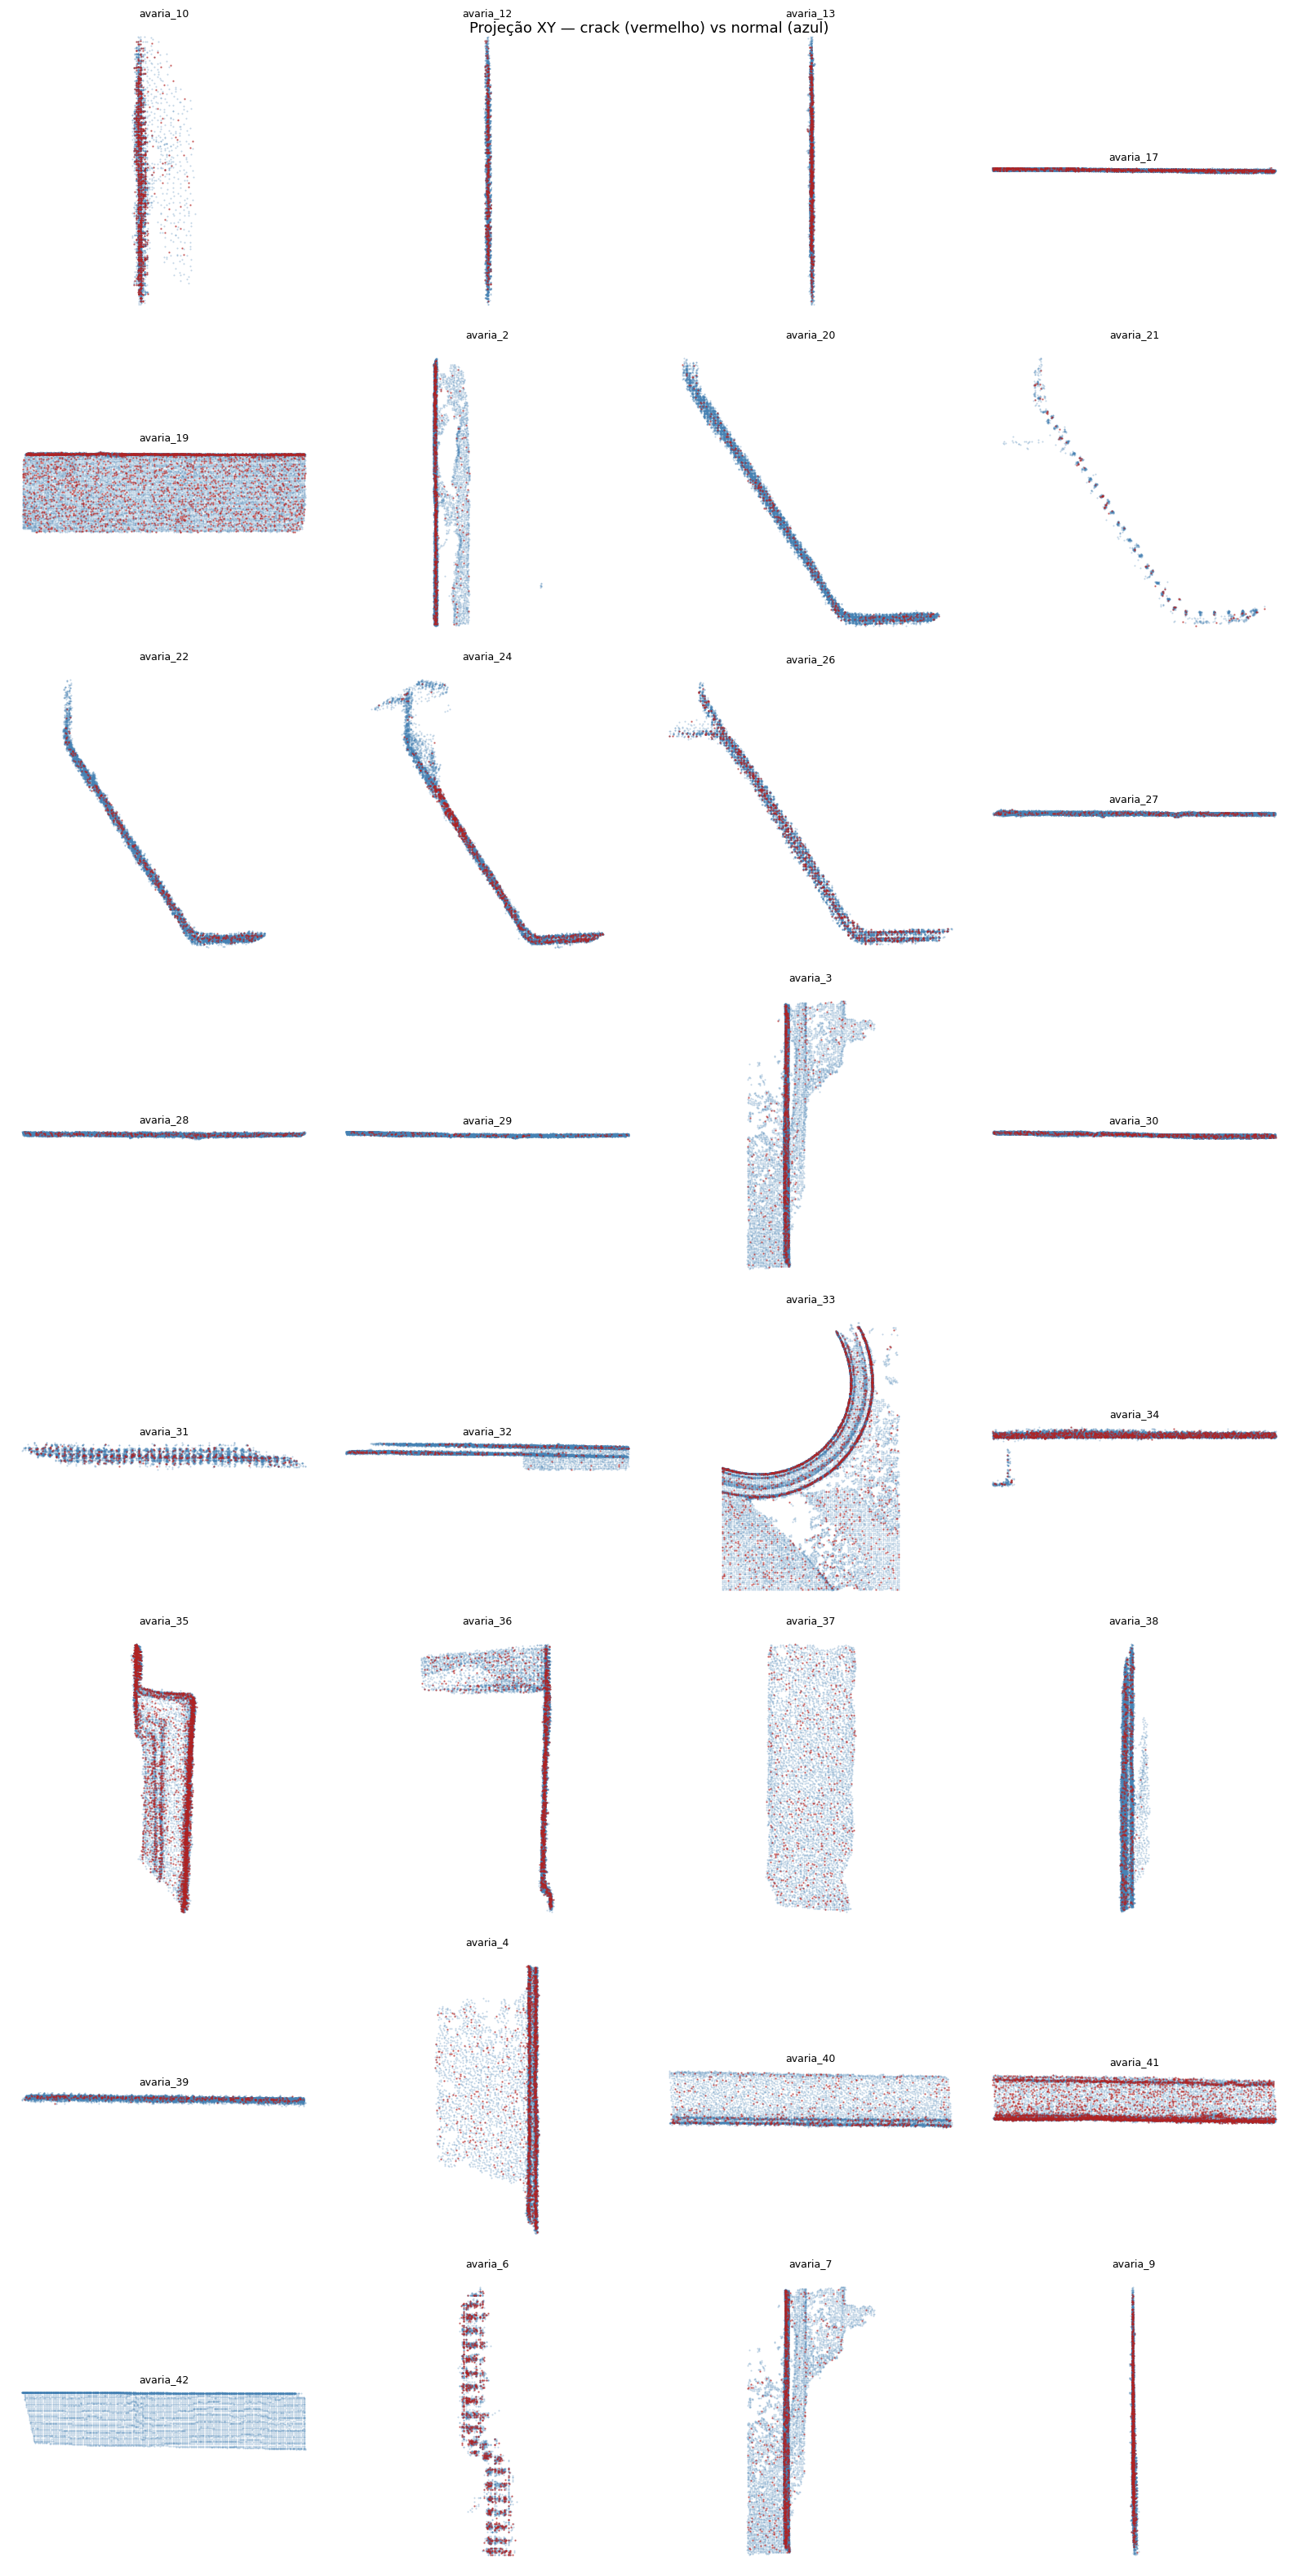

In [4]:
ncols = 4
nrows = (len(crack_clouds) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, d in zip(axes, sorted(crack_clouds, key=lambda x: x['filename'])):
  xyz    = d['features'][:, :3]
  labels = (d['labels'] > 0)
  ax.scatter(xyz[~labels, 0], xyz[~labels, 1], s=0.3, c='steelblue', alpha=0.3, label='normal')
  ax.scatter(xyz[labels,  0], xyz[labels,  1], s=0.5, c='firebrick', alpha=0.6, label='crack')
  ax.set_title(d['filename'].replace('.ply',''), fontsize=9)
  ax.set_aspect('equal')
  ax.axis('off')

for ax in axes[len(crack_clouds):]:
  ax.set_visible(False)

plt.suptitle('Projeção XY — crack (vermelho) vs normal (azul)', fontsize=13)
plt.tight_layout()
plt.savefig('../visualizations_sf/spatial_xy.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
K = 16
print(f"{'Arquivo':<35} {'%viz_crack(crack)':>18} {'%viz_crack(normal)':>19} {'separabilidade':>15}")
print("-" * 90)

neigh_results = []
for d in sorted(crack_clouds, key=lambda x: x['filename']):
  xyz    = d['features'][:, :3]
  labels = (d['labels'] > 0).astype(int)
  if labels.sum() < 10:
      continue

  tree = cKDTree(xyz)
  _, idx = tree.query(xyz, k=K+1, workers=-1)
  idx = idx[:, 1:]  # remove self

  neigh_labels = labels[idx]              # (N, K)
  frac_crack   = neigh_labels.mean(axis=1)  # fração de vizinhos crack por ponto

  crack_mask  = labels == 1
  normal_mask = labels == 0

  mean_crack_in_crack   = frac_crack[crack_mask].mean()
  mean_crack_in_normal  = frac_crack[normal_mask].mean()
  separabilidade        = mean_crack_in_crack - mean_crack_in_normal

  neigh_results.append({
      'filename': d['filename'],
      'viz_crack_pts':   mean_crack_in_crack,
      'viz_normal_pts':  mean_crack_in_normal,
      'sep': separabilidade,
  })
  print(f"{d['filename']:<35} {mean_crack_in_crack:>18.4f} {mean_crack_in_normal:>19.4f} {separabilidade:>15.4f}")

seps = [r['sep'] for r in neigh_results]
print(f"\nSeparabilidade média: {np.mean(seps):.4f}  (quanto maior, mais o EdgeConv ajuda)")


Arquivo                              %viz_crack(crack)  %viz_crack(normal)  separabilidade
------------------------------------------------------------------------------------------
avaria_10.ply                                   0.1338              0.1324          0.0014
avaria_12.ply                                   0.0584              0.0571          0.0012
avaria_13.ply                                   0.0639              0.0666         -0.0027
avaria_17.ply                                   0.0412              0.0423         -0.0011
avaria_19.ply                                   0.1261              0.1236          0.0024
avaria_2.ply                                    0.0355              0.0332          0.0023
avaria_20.ply                                   0.0251              0.0225          0.0026
avaria_21.ply                                   0.0605              0.0605         -0.0000
avaria_22.ply                                   0.0339              0.0320          0.0019

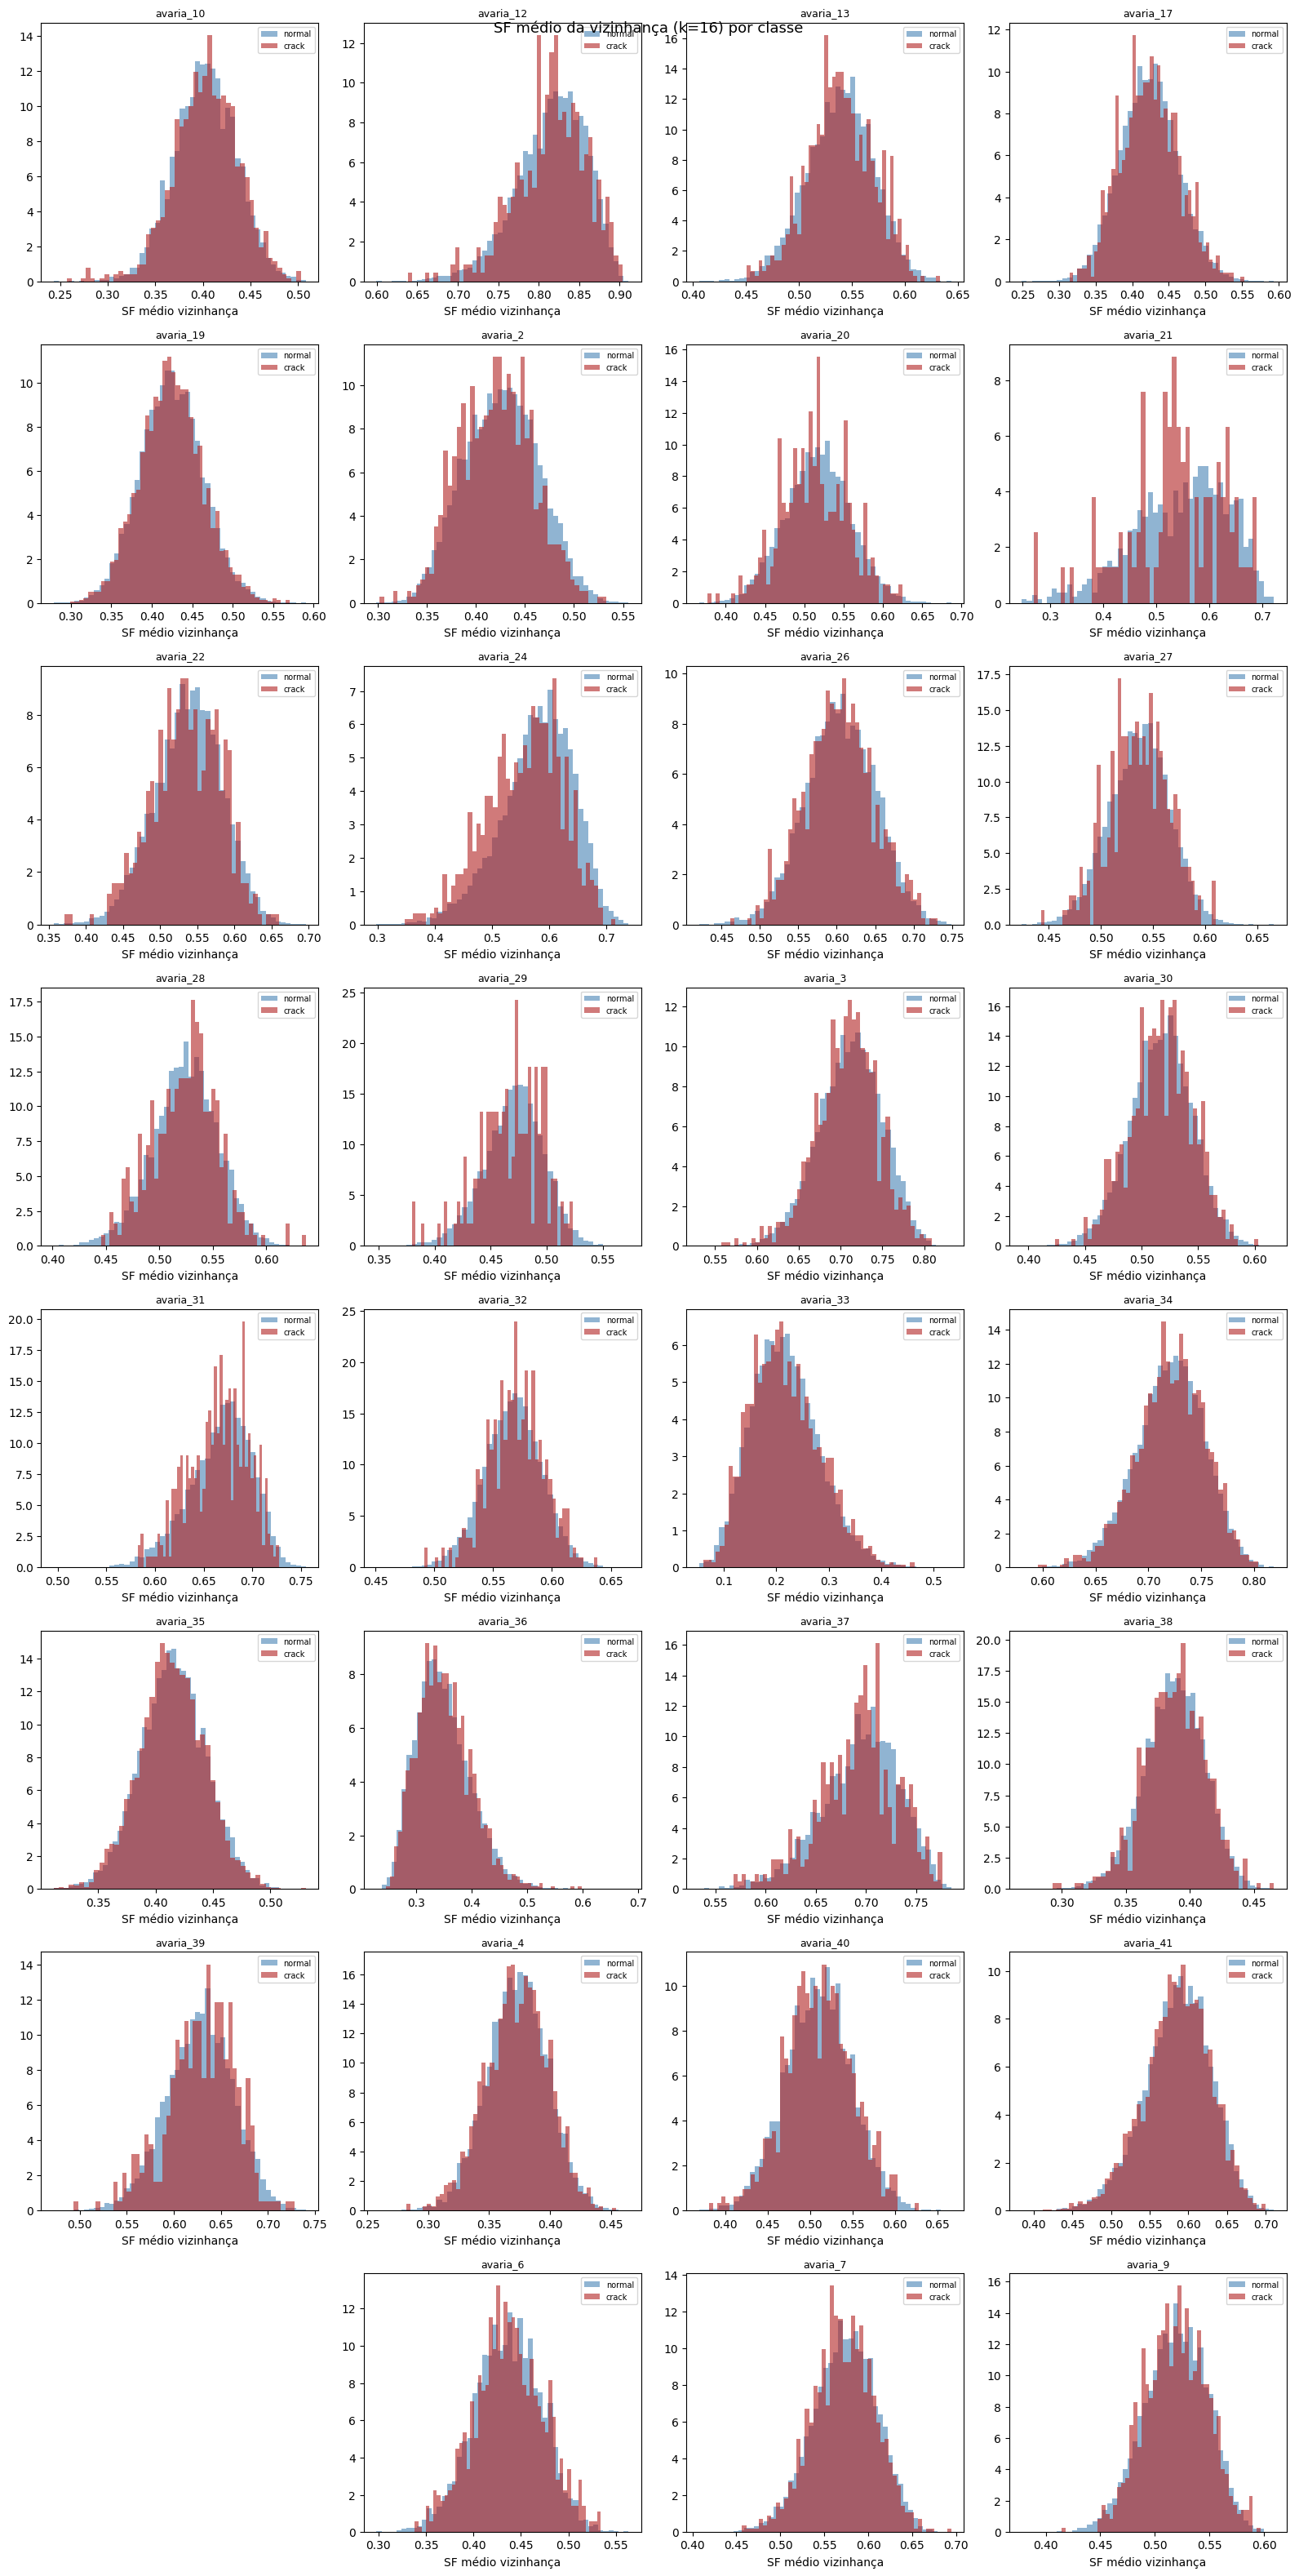

In [7]:
K = 16
ncols = 4
nrows = (len(crack_clouds) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, d in zip(axes, sorted(crack_clouds, key=lambda x: x['filename'])):
  xyz    = d['features'][:, :3]
  sf     = d['features'][:, 9]
  labels = (d['labels'] > 0).astype(int)
  if labels.sum() < 10:
      ax.set_visible(False)
      continue

  tree = cKDTree(xyz)
  _, idx = tree.query(xyz, k=K+1, workers=-1)
  idx = idx[:, 1:]
  sf_neigh_mean = sf[idx].mean(axis=1)   # SF médio da vizinhança por ponto

  crack_mask  = labels == 1
  normal_mask = labels == 0

  ax.hist(sf_neigh_mean[normal_mask], bins=50, alpha=0.6,
          color='steelblue', density=True, label='normal')
  ax.hist(sf_neigh_mean[crack_mask],  bins=50, alpha=0.6,
          color='firebrick', density=True, label='crack')
  ax.set_title(d['filename'].replace('.ply',''), fontsize=9)
  ax.set_xlabel('SF médio vizinhança')
  ax.legend(fontsize=7)

for ax in axes[len(crack_clouds):]:
  ax.set_visible(False)

plt.suptitle('SF médio da vizinhança (k=16) por classe', fontsize=13)
plt.tight_layout()
plt.savefig('../visualizations_sf/sf_neighborhood.png', dpi=150, bbox_inches='tight')
plt.show()

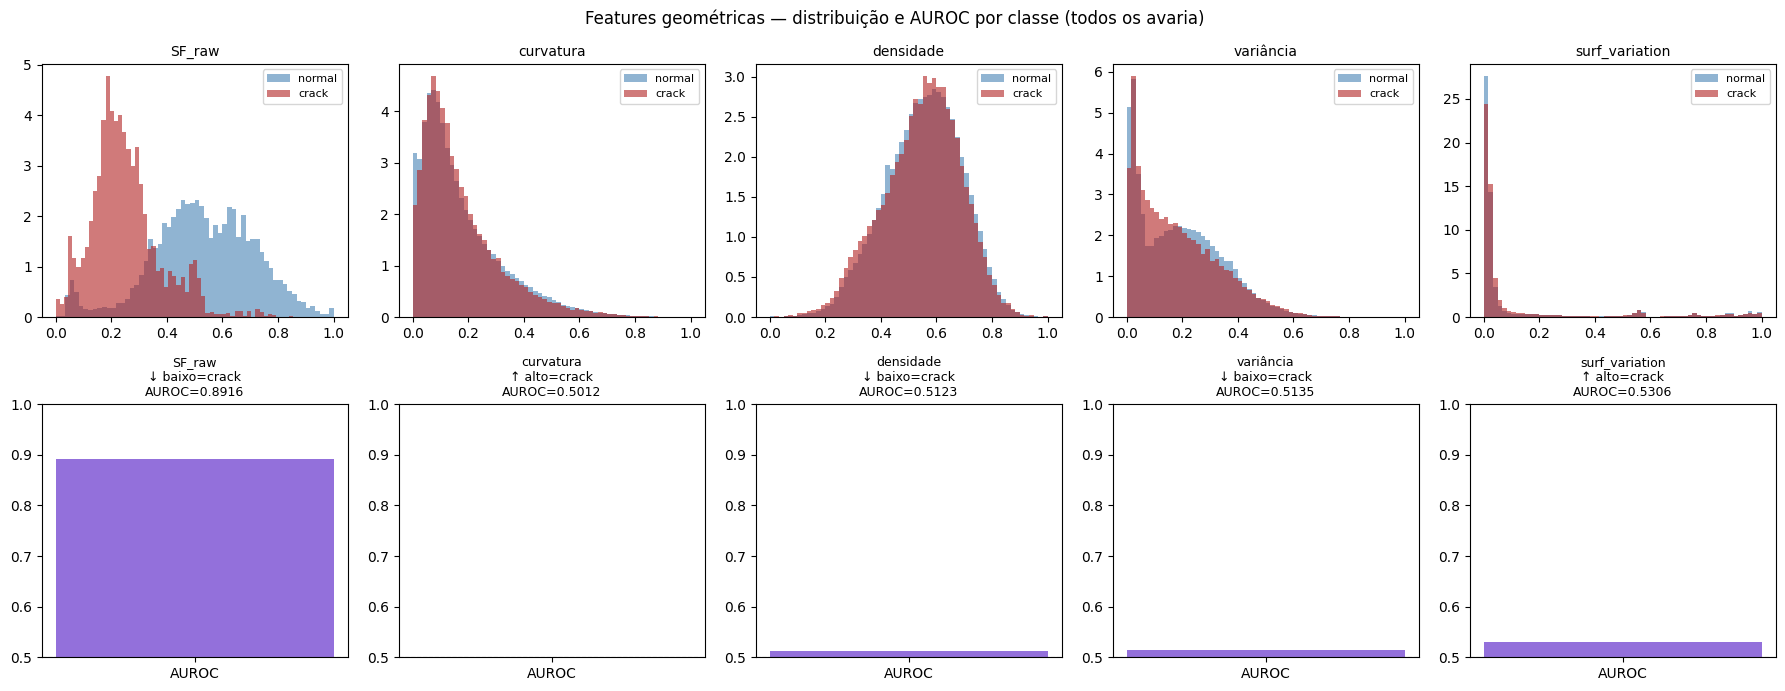

In [6]:
import matplotlib.gridspec as gridspec

feature_names = {9: 'SF_raw', 10: 'curvatura', 11: 'densidade', 12: 'variância', 13: 'surf_variation'}
cols = list(feature_names.keys())

# Agrega todos os pontos de todas as nuvens de avaria
all_feats  = np.concatenate([d['features'] for d in crack_clouds], axis=0)
all_labels = np.concatenate([(d['labels'] > 0).astype(int) for d in crack_clouds])

crack_pts  = all_feats[all_labels == 1]
normal_pts = all_feats[all_labels == 0]

fig, axes = plt.subplots(2, len(cols), figsize=(18, 7))

for i, col in enumerate(cols):
  name = feature_names[col]
  # Distribuição por classe
  axes[0, i].hist(normal_pts[:, col], bins=60, alpha=0.6,
                  color='steelblue', density=True, label='normal')
  axes[0, i].hist(crack_pts[:, col],  bins=60, alpha=0.6,
                  color='firebrick', density=True, label='crack')
  axes[0, i].set_title(name, fontsize=10)
  axes[0, i].legend(fontsize=8)

  # AUROC dessa feature isolada
  try:
      auroc_pos = roc_auc_score(all_labels, all_feats[:, col])
      auroc_neg = roc_auc_score(all_labels, -all_feats[:, col])
      auroc_f   = max(auroc_pos, auroc_neg)
      direction = '↓ baixo=crack' if auroc_neg > auroc_pos else '↑ alto=crack'
  except:
      auroc_f, direction = 0.5, '?'

  axes[1, i].bar(['AUROC'], [auroc_f], color='mediumpurple')
  axes[1, i].set_ylim(0.5, 1.0)
  axes[1, i].set_title(f'{name}\n{direction}\nAUROC={auroc_f:.4f}', fontsize=9)
  axes[1, i].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Features geométricas — distribuição e AUROC por classe (todos os avaria)', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations_sf/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from plyfile import PlyData
from pathlib import Path
import numpy as np

data_paths = list(Path('../data/train').glob('**/*.ply')) + \
           list(Path('../data/test').glob('**/*.ply'))

print(f"{'Arquivo':<35} {'SF_min':>8} {'SF_max':>8} {'SF_mean':>8} {'n_crack':>8}")
print("-" * 75)

results = []
for path in sorted(data_paths):
  fname = path.name.lower()
  has_crack = ('avaria' in fname) and ('n_avaria' not in fname)
  if not has_crack:
      continue

  ply   = PlyData.read(str(path))
  v     = ply['vertex']
  props = list(v.data.dtype.names)

  # Scalar field bruto
  sf_cols = [c for c in props if 'scalar' in c.lower()
             and 'label' not in c.lower() and 'original' not in c.lower()]
  if not sf_cols:
      print(f"{path.name:<35} {'sem SF':>8}")
      continue
  sf = v[sf_cols[0]].astype(np.float32)

  # scalar_labels
  lbl_cols = [c for c in props if c.lower() == 'scalar_labels']
  if not lbl_cols:
      lbl_cols = [c for c in props if 'label' in c.lower()]

  if not lbl_cols:
      print(f"{path.name:<35} {'sem labels':>8}")
      continue

  labels = v[lbl_cols[0]].astype(np.int64)
  crack_mask = labels == 1

  if crack_mask.sum() == 0:
      print(f"{path.name:<35} {'0 cracks':>8}")
      continue

  sf_crack = sf[crack_mask]
  row = {
      'filename': path.name,
      'sf_min'  : float(sf_crack.min()),
      'sf_max'  : float(sf_crack.max()),
      'sf_mean' : float(sf_crack.mean()),
      'n_crack' : int(crack_mask.sum()),
  }
  results.append(row)
  print(f"{path.name:<35} {row['sf_min']:>8.2f} {row['sf_max']:>8.2f} "
        f"{row['sf_mean']:>8.2f} {row['n_crack']:>8,}")

# Range global dos cracks
all_mins = [r['sf_min'] for r in results]
all_maxs = [r['sf_max'] for r in results]
print(f"\nRange global dos pontos de crack:")
print(f"  SF mínimo absoluto: {min(all_mins):.2f}")
print(f"  SF máximo absoluto: {max(all_maxs):.2f}")

Arquivo                               SF_min   SF_max  SF_mean  n_crack
---------------------------------------------------------------------------
avaria_10.ply                           0.00    27.00    18.21    1,265
avaria_12.ply                          27.00    60.00    40.74      457
avaria_13.ply                          27.00    60.00    45.37      832
avaria_17.ply                           2.00   118.00    47.00    6,052
avaria_19.ply                           4.00    98.00    37.74    6,584
avaria_2.ply                            0.00    29.00    20.89    2,000
avaria_20.ply                           4.00    58.00    32.03      446
avaria_21.ply                           4.00   107.00    38.30      585
avaria_22.ply                           4.00    77.00    32.12      501
avaria_23.ply                           4.00    77.00    32.12      501
avaria_24.ply                           4.00    81.00    34.56      926
avaria_25.ply                           4.00    81.00    34.

In [12]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

crack_clouds_raw = []
for path in sorted(Path('../data/train').glob('**/*.ply')) + sorted(Path('../data/test').glob('**/*.ply')):
  fname = path.name.lower()
  if not (('avaria' in fname) and ('n_avaria' not in fname)):
      continue
  ply   = PlyData.read(str(path))
  v     = ply['vertex']
  props = list(v.data.dtype.names)
  sf_cols  = [c for c in props if 'scalar' in c.lower() and 'label' not in c.lower() and 'original' not in
c.lower()]
  lbl_cols = [c for c in props if c.lower() == 'scalar_labels']
  if not sf_cols or not lbl_cols:
      continue
  sf     = v[sf_cols[0]].astype(np.float32)
  labels = (v[lbl_cols[0]].astype(np.int64) == 1).astype(int)
  if labels.sum() == 0:
      continue
  crack_clouds_raw.append({'filename': path.name, 'sf': sf, 'labels': labels})

print(f"{len(crack_clouds_raw)} nuvens carregadas com labels")

34 nuvens carregadas com labels


In [13]:

print(f"{'Arquivo':<35} {'%crack':>8} {'n_crack':>8} {'n_total':>8}  {'impacto_visual'}")
print("-" * 85)

for d in crack_clouds_raw:
  pct   = d['labels'].mean() * 100
  n_c   = d['labels'].sum()
  n_t   = len(d['labels'])
  impacto = "BAIXO (<5%)" if pct < 5 else ("MÉDIO" if pct < 15 else "ALTO")
  print(f"{d['filename']:<35} {pct:>7.1f}% {n_c:>8,} {n_t:>8,}  {impacto}")

Arquivo                               %crack  n_crack  n_total  impacto_visual
-------------------------------------------------------------------------------------
avaria_10.ply                          14.1%    1,265    8,964  MÉDIO
avaria_12.ply                           5.6%      457    8,169  MÉDIO
avaria_13.ply                           6.5%      832   12,792  MÉDIO
avaria_17.ply                           4.9%    6,052  123,845  BAIXO (<5%)
avaria_19.ply                           9.5%    6,584   69,022  MÉDIO
avaria_2.ply                            4.6%    2,000   43,172  BAIXO (<5%)
avaria_20.ply                           2.7%      446   16,706  BAIXO (<5%)
avaria_21.ply                           3.0%      585   19,307  BAIXO (<5%)
avaria_22.ply                           3.5%      501   14,187  BAIXO (<5%)
avaria_23.ply                           3.5%      501   14,187  BAIXO (<5%)
avaria_24.ply                           6.6%      926   14,021  MÉDIO
avaria_25.ply                

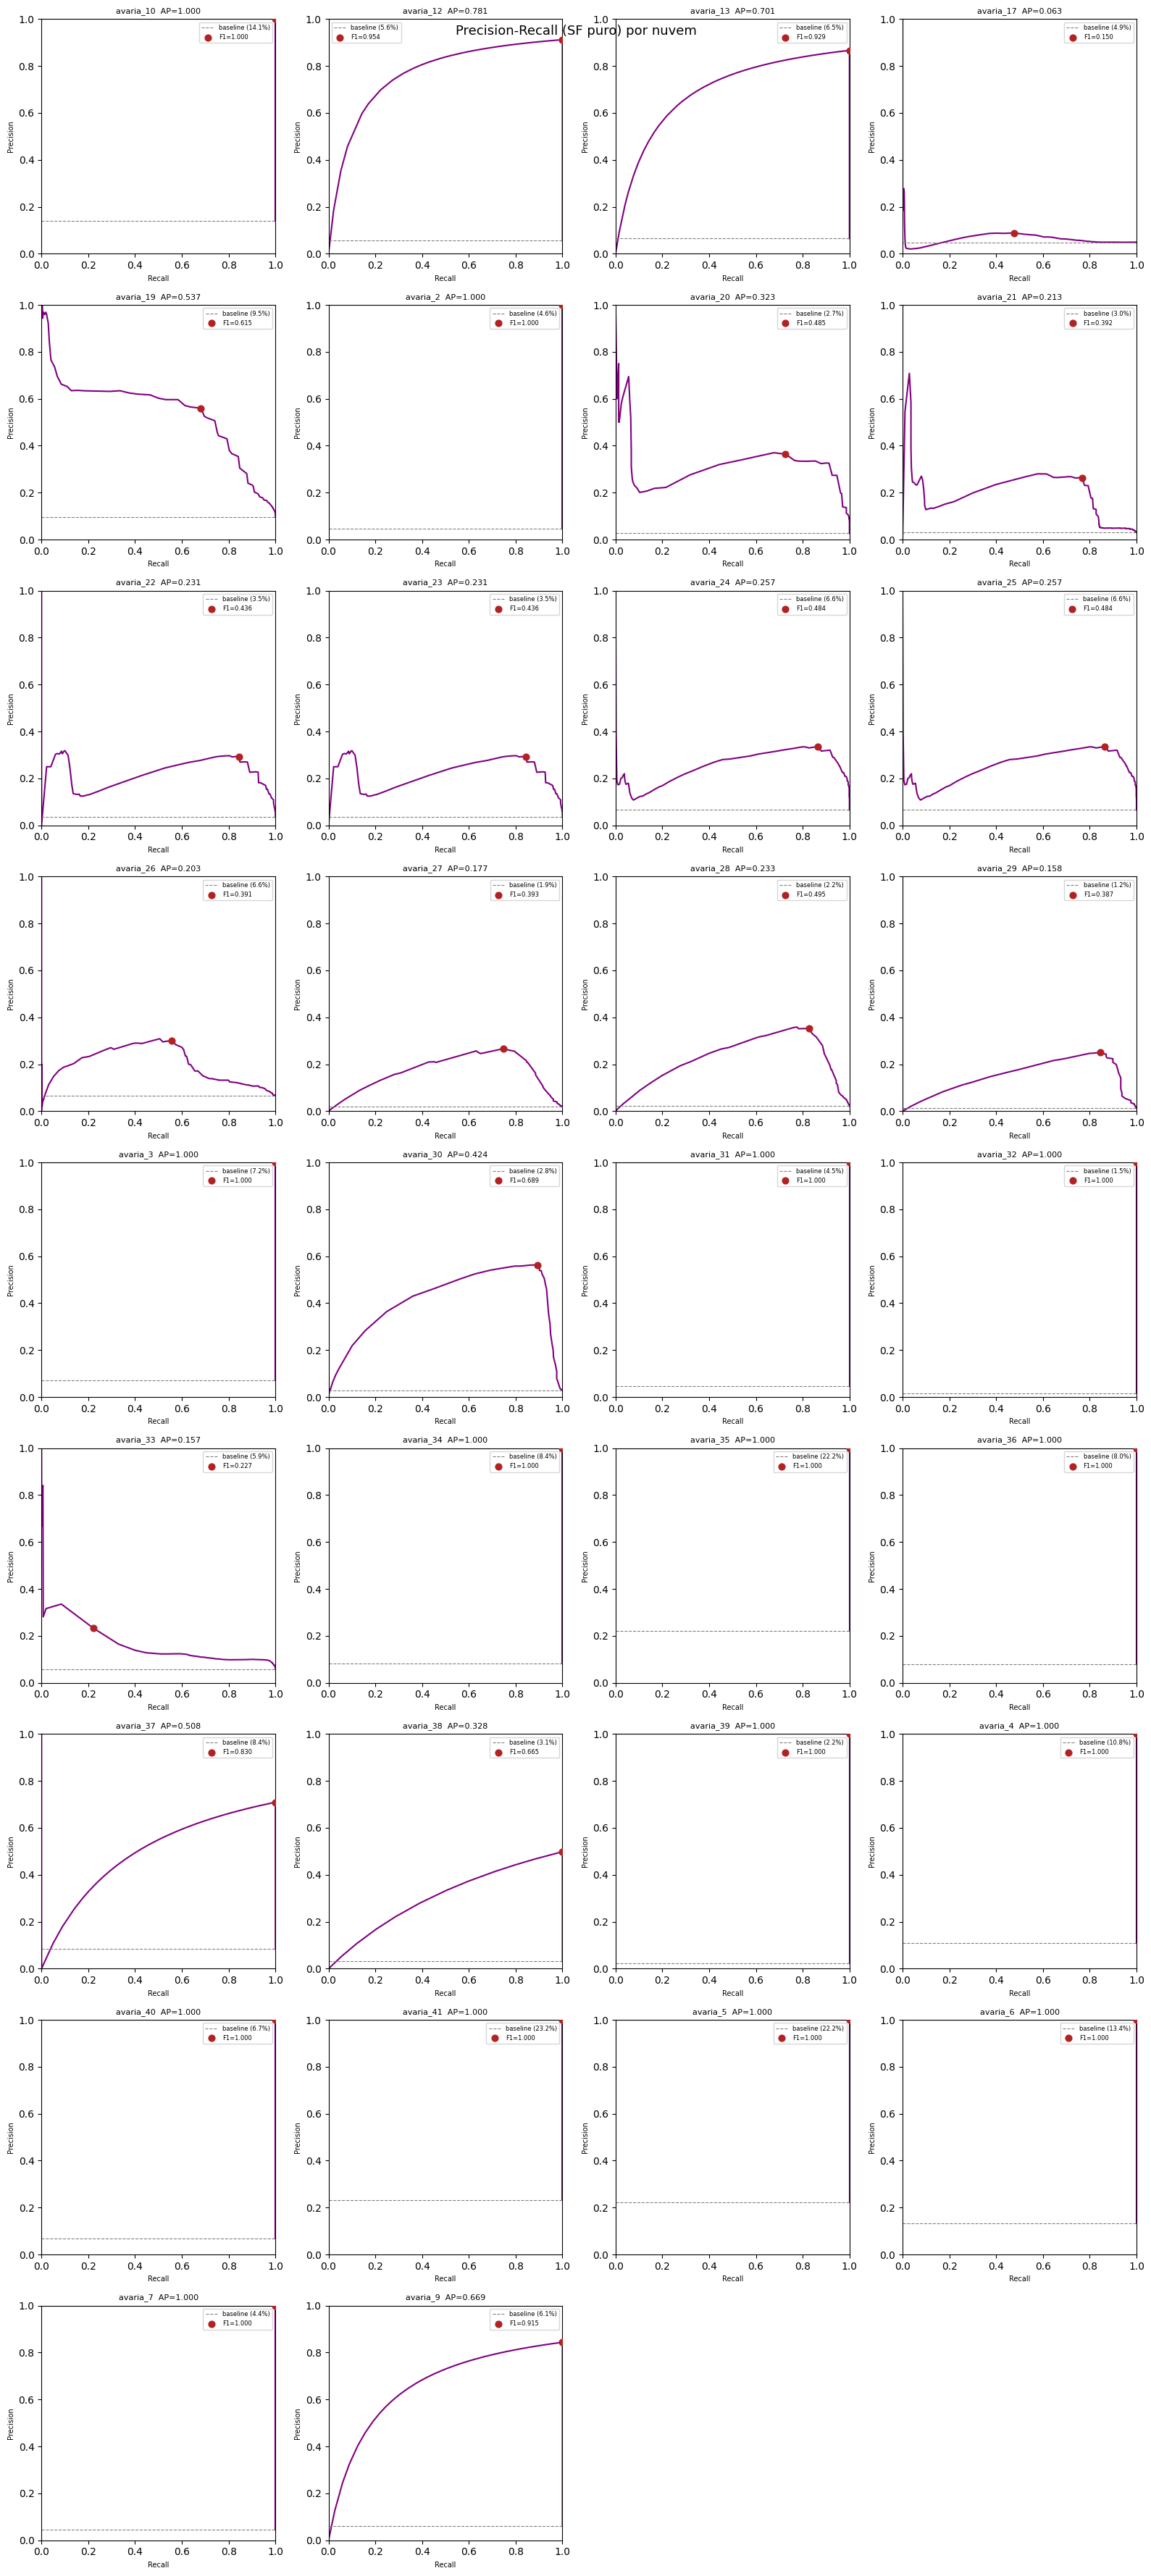

In [14]:
ncols = 4
nrows = (len(crack_clouds_raw) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, d in zip(axes, crack_clouds_raw):
  labels = d['labels']
  score  = -d['sf']   # SF baixo = crack → inverte para score alto = crack

  prec, rec, thrs = precision_recall_curve(labels, score)
  ap  = average_precision_score(labels, score)
  pct = labels.mean() * 100

  ax.plot(rec, prec, color='purple', linewidth=1.5)
  ax.axhline(labels.mean(), color='gray', linestyle='--', linewidth=0.8,
             label=f'baseline ({pct:.1f}%)')

  # Marca o ponto de F1 máximo
  f1s    = 2 * prec * rec / (prec + rec + 1e-8)
  best_i = np.argmax(f1s)
  ax.scatter(rec[best_i], prec[best_i], color='firebrick', s=40, zorder=5,
             label=f'F1={f1s[best_i]:.3f}')

  ax.set_xlim(0, 1)
  ax.set_ylim(0, 1)
  ax.set_title(f"{d['filename'].replace('.ply','')}  AP={ap:.3f}", fontsize=8)
  ax.set_xlabel('Recall', fontsize=7)
  ax.set_ylabel('Precision', fontsize=7)
  ax.legend(fontsize=6)

for ax in axes[len(crack_clouds_raw):]:
  ax.set_visible(False)

plt.suptitle('Precision-Recall (SF puro) por nuvem', fontsize=13)
plt.tight_layout()
plt.savefig('../visualizations_sf/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print(f"{'Arquivo':<35} {'thr_F1':>8} {'P@F1':>7} {'R@F1':>7} {'F1':>7} {'%pred_crack':>12}")
print("-" * 85)

for d in crack_clouds_raw:
  labels = d['labels']
  score  = -d['sf']

  prec, rec, thrs = precision_recall_curve(labels, score)
  f1s    = 2 * prec * rec / (prec + rec + 1e-8)
  best_i = np.argmax(f1s[:-1])   # last element tem threshold definido

  best_thr = thrs[best_i]
  preds    = (score >= best_thr).astype(int)
  pct_pred = preds.mean() * 100

  print(f"{d['filename']:<35} {-best_thr:>8.1f} "
        f"{prec[best_i]:>7.3f} {rec[best_i]:>7.3f} {f1s[best_i]:>7.3f} "
        f"{pct_pred:>11.1f}%")

Arquivo                               thr_F1    P@F1    R@F1      F1  %pred_crack
-------------------------------------------------------------------------------------
avaria_10.ply                           27.0   1.000   1.000   1.000        14.1%
avaria_12.ply                           60.0   0.912   1.000   0.954         6.1%
avaria_13.ply                           60.0   0.867   1.000   0.929         7.5%
avaria_17.ply                           40.0   0.089   0.477   0.150        26.3%
avaria_19.ply                           40.0   0.560   0.682   0.615        11.6%
avaria_2.ply                            29.0   1.000   1.000   1.000         4.6%
avaria_20.ply                           34.0   0.364   0.726   0.485         5.3%
avaria_21.ply                           43.0   0.263   0.768   0.392         8.8%
avaria_22.ply                           43.0   0.294   0.844   0.436        10.2%
avaria_23.ply                           43.0   0.294   0.844   0.436        10.2%
avaria_24.pl

In [16]:
all_data     = load_folder('../data/train') + load_folder('../data/test')
crack_clouds = [d for d in all_data if d['has_crack']]

print(f"{'Arquivo':<35} {'AUROC_SF':>9} {'AUROC_lum':>10} {'AUROC_sat':>10} {'AUROC_lum+SF':>13}")
print("-" * 85)

rows = []
for d in sorted(crack_clouds, key=lambda x: x['filename']):
  labels = (d['labels'] > 0).astype(int)
  if labels.sum() == 0 or (labels == 0).sum() == 0:
      continue

  sf  = d['features'][:, 9]
  lum = d['features'][:, 14]
  sat = d['features'][:, 15]

  auroc_sf  = roc_auc_score(labels, -sf)
  auroc_lum = roc_auc_score(labels, -lum)
  auroc_sat = roc_auc_score(labels, -sat)

  # Combinação simples: média SF e lum
  combined  = (-sf + -lum) / 2
  auroc_comb = roc_auc_score(labels, combined)

  rows.append({
      'filename': d['filename'],
      'auroc_sf': auroc_sf, 'auroc_lum': auroc_lum,
      'auroc_sat': auroc_sat, 'auroc_comb': auroc_comb,
  })
  flag = ' ◄' if auroc_lum > auroc_sf + 0.05 else ''
  print(f"{d['filename']:<35} {auroc_sf:>9.4f} {auroc_lum:>10.4f} "
        f"{auroc_sat:>10.4f} {auroc_comb:>13.4f}{flag}")

aurocs_sf   = [r['auroc_sf']   for r in rows]
aurocs_lum  = [r['auroc_lum']  for r in rows]
aurocs_comb = [r['auroc_comb'] for r in rows]
print(f"\n{'MÉDIA':<35} {np.mean(aurocs_sf):>9.4f} {np.mean(aurocs_lum):>10.4f} "
    f"{'':>10} {np.mean(aurocs_comb):>13.4f}")

21:30:23 | INFO | Encontrados 64 arquivos PLY em ../data/train
21:30:23 - INFO: Encontrados 64 arquivos PLY em ../data/train
21:30:24 | INFO |   OK avaria_10.ply | 7,971 pts | crack=True
21:30:24 - INFO:   OK avaria_10.ply | 7,971 pts | crack=True
21:30:25 | INFO |   OK avaria_12.ply | 7,636 pts | crack=True
21:30:25 - INFO:   OK avaria_12.ply | 7,636 pts | crack=True
21:30:26 | INFO |   OK avaria_13.ply | 11,880 pts | crack=True
21:30:26 - INFO:   OK avaria_13.ply | 11,880 pts | crack=True
21:30:31 | INFO |   OK avaria_17.ply | 24,367 pts | crack=True
21:30:31 - INFO:   OK avaria_17.ply | 24,367 pts | crack=True
21:30:34 | INFO |   OK avaria_19.ply | 22,914 pts | crack=True
21:30:34 - INFO:   OK avaria_19.ply | 22,914 pts | crack=True
21:30:37 | INFO |   OK avaria_2.ply | 23,988 pts | crack=True
21:30:37 - INFO:   OK avaria_2.ply | 23,988 pts | crack=True
21:30:39 | INFO |   OK avaria_20.ply | 15,509 pts | crack=True
21:30:39 - INFO:   OK avaria_20.ply | 15,509 pts | crack=True
21:30:

Arquivo                              AUROC_SF  AUROC_lum  AUROC_sat  AUROC_lum+SF
-------------------------------------------------------------------------------------
avaria_10.ply                          1.0000     0.5167     0.4962        0.9809
avaria_12.ply                          0.9946     0.5201     0.4937        0.9945
avaria_13.ply                          0.9888     0.5031     0.4906        0.9797
avaria_17.ply                          0.5335     0.4882     0.4886        0.5188
avaria_19.ply                          0.9049     0.5040     0.4925        0.8664
avaria_2.ply                           1.0000     0.4813     0.4894        0.9852
avaria_20.ply                          0.9718     0.5273     0.4502        0.9342
avaria_21.ply                          0.6110     0.4889     0.5155        0.5711
avaria_22.ply                          0.9431     0.5069     0.4979        0.8974
avaria_24.ply                          0.9203     0.4988     0.5015        0.8791
avaria_26.pl

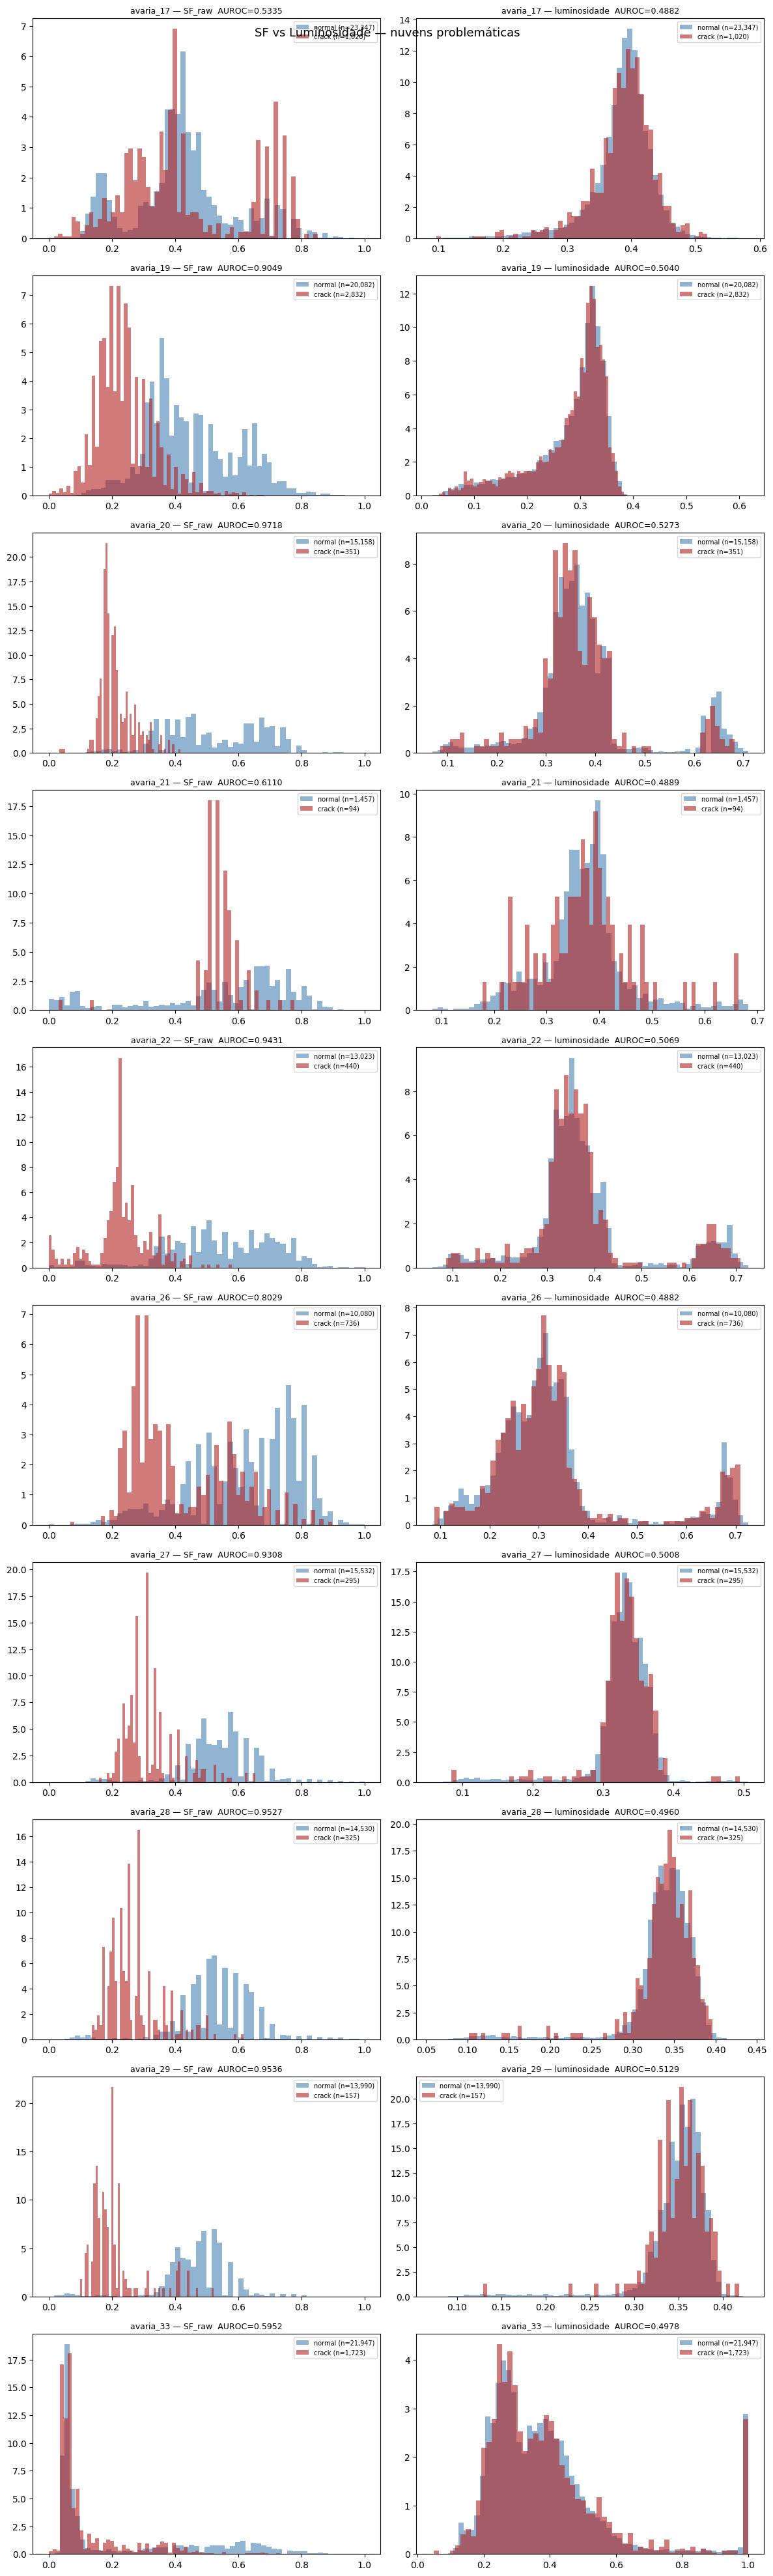

In [17]:
import matplotlib.pyplot as plt

problematic = ['avaria_17.ply', 'avaria_33.ply', 'avaria_26.ply',
             'avaria_21.ply', 'avaria_22.ply', 'avaria_19.ply',
             'avaria_20.ply', 'avaria_27.ply', 'avaria_28.ply', 'avaria_29.ply']

prob_data = [d for d in crack_clouds if d['filename'] in problematic]

fig, axes = plt.subplots(len(prob_data), 2, figsize=(12, 4*len(prob_data)))

for i, d in enumerate(sorted(prob_data, key=lambda x: x['filename'])):
  labels = (d['labels'] > 0).astype(int)
  sf     = d['features'][:, 9]
  lum    = d['features'][:, 14]

  for ax, feat, name, col in zip(
      [axes[i,0], axes[i,1]],
      [sf, lum],
      ['SF_raw', 'luminosidade'],
      ['purple', 'darkorange']
  ):
      crack_f  = feat[labels == 1]
      normal_f = feat[labels == 0]
      ax.hist(normal_f, bins=60, alpha=0.6, color='steelblue',
              density=True, label=f'normal (n={len(normal_f):,})')
      ax.hist(crack_f,  bins=60, alpha=0.6, color='firebrick',
              density=True, label=f'crack (n={len(crack_f):,})')
      auroc = roc_auc_score(labels, -feat)
      ax.set_title(f"{d['filename'].replace('.ply','')} — {name}  AUROC={auroc:.4f}", fontsize=9)
      ax.legend(fontsize=7)

plt.suptitle('SF vs Luminosidade — nuvens problemáticas', fontsize=13)
plt.tight_layout()
plt.savefig('../visualizations_sf/sf_vs_lum_problematic.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np

feature_names = [
  'x', 'y', 'z',
  'R', 'G', 'B',
  'nx', 'ny', 'nz',
  'SF', 'curvatura', 'densidade', 'variancia', 'surf_var',
  'lum', 'sat', 'label'
]

# Agrega todos os pontos de avaria
chunks = []
for d in crack_clouds:
  feats  = d['features']                          # (N, 16)
  labels = (d['labels'] > 0).astype(np.float32).reshape(-1, 1)
  chunks.append(np.concatenate([feats, labels], axis=1))

all_pts = np.concatenate(chunks, axis=0)
df      = pd.DataFrame(all_pts, columns=feature_names)

print(f"Total de pontos: {len(df):,}  |  crack: {int(df['label'].sum()):,}  "
    f"({df['label'].mean()*100:.1f}%)")

Total de pontos: 486,025  |  crack: 30,826  (6.3%)


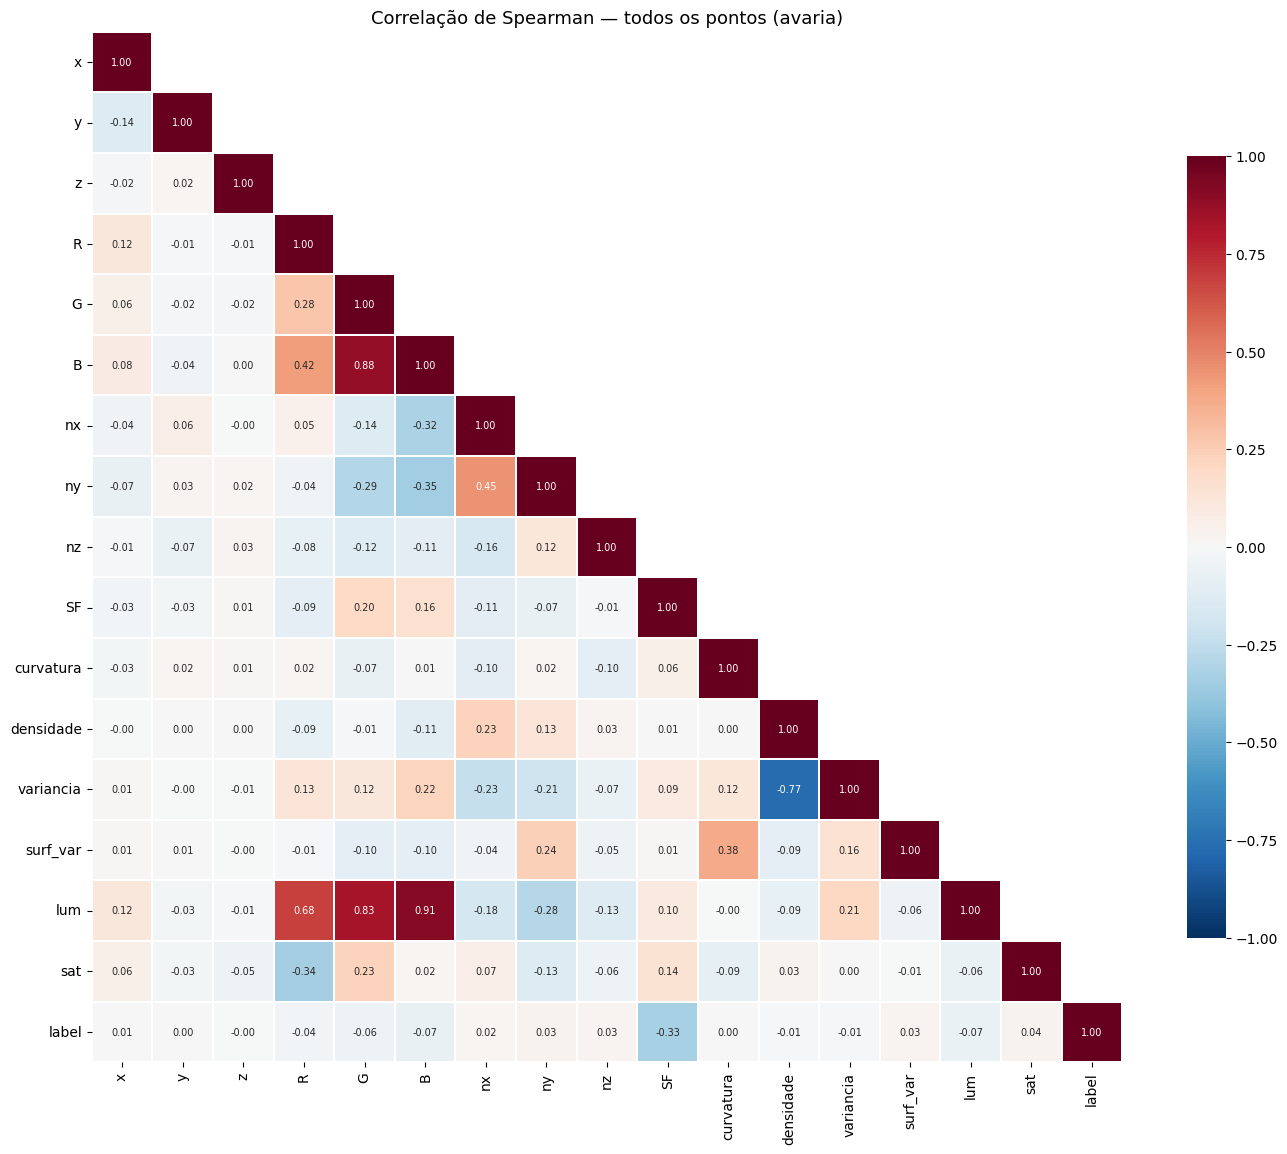

In [19]:
corr, pval = spearmanr(df)
corr_df    = pd.DataFrame(corr, index=feature_names, columns=feature_names)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # mostra triângulo inferior

sns.heatmap(
  corr_df, mask=mask,
  annot=True, fmt='.2f', annot_kws={'size': 7},
  cmap='RdBu_r', center=0, vmin=-1, vmax=1,
  square=True, linewidths=0.3, ax=ax,
  cbar_kws={'shrink': 0.7}
)
ax.set_title('Correlação de Spearman — todos os pontos (avaria)', fontsize=13)
plt.tight_layout()
plt.savefig('../visualizations_sf/spearman_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
feat_cols = ['SF', 'curvatura', 'densidade', 'variancia',
           'surf_var', 'lum', 'sat', 'R', 'G', 'B']

corr_per_cloud = []
for d in sorted(crack_clouds, key=lambda x: x['filename']):
  labels = (d['labels'] > 0).astype(np.float32)
  if labels.sum() == 0:
      continue
  feats = d['features']
  feat_map = {
      'SF': feats[:,9], 'curvatura': feats[:,10], 'densidade': feats[:,11],
      'variancia': feats[:,12], 'surf_var': feats[:,13],
      'lum': feats[:,14], 'sat': feats[:,15],
      'R': feats[:,3], 'G': feats[:,4], 'B': feats[:,5],
  }
  row = {'filename': d['filename'].replace('.ply','')}
  for name, values in feat_map.items():
      r, _ = spearmanr(values, labels)
      row[name] = round(float(r), 3)
  corr_per_cloud.append(row)

corr_cloud_df = pd.DataFrame(corr_per_cloud).set_index('filename')
print(corr_cloud_df.to_string())

              SF  curvatura  densidade  variancia  surf_var    lum    sat      R      G      B
filename                                                                                      
avaria_10 -0.587      0.005      0.007      0.001    -0.006 -0.020  0.004 -0.009 -0.012 -0.021
avaria_12 -0.400      0.012      0.013     -0.006     0.007 -0.016  0.005 -0.013  0.006  0.011
avaria_13 -0.423      0.007      0.002      0.000     0.000 -0.003  0.008 -0.002  0.004 -0.005
avaria_17 -0.023      0.004      0.009     -0.009    -0.002  0.008  0.008  0.012  0.006  0.005
avaria_19 -0.462      0.004     -0.014      0.012     0.005 -0.005  0.009 -0.005 -0.007 -0.002
avaria_2  -0.311      0.005     -0.003     -0.003    -0.006  0.012  0.007  0.016  0.006  0.008
avaria_20 -0.243      0.002      0.000     -0.006     0.014 -0.014  0.026 -0.014 -0.016 -0.010
avaria_21 -0.092      0.008      0.074     -0.063     0.019  0.009 -0.013  0.020  0.011 -0.002
avaria_22 -0.273     -0.017     -0.007      0.005 

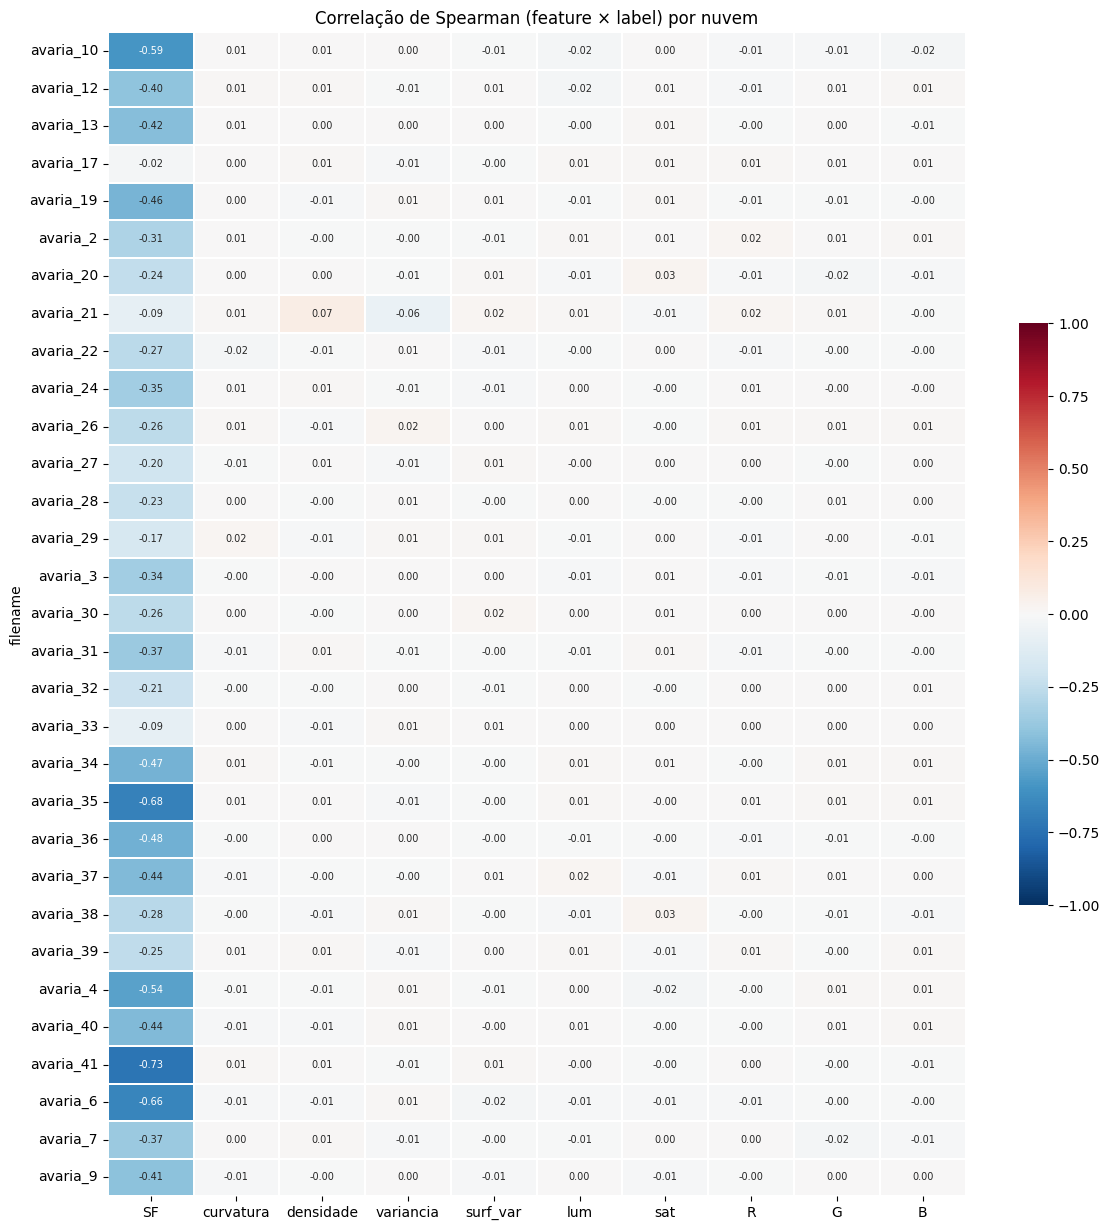

In [21]:
fig, ax = plt.subplots(figsize=(12, max(8, len(corr_cloud_df)*0.4)))
sns.heatmap(
  corr_cloud_df, annot=True, fmt='.2f', annot_kws={'size': 7},
  cmap='RdBu_r', center=0, vmin=-1, vmax=1,
  linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.5}
)
ax.set_title('Correlação de Spearman (feature × label) por nuvem', fontsize=12)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../visualizations_sf/spearman_per_cloud.png', dpi=150, bbox_inches='tight')
plt.show()